# Notebook 7: Phân Tích Sinh Tồn (Survival Analysis) - Đỉnh Cao Lâm Sàng

<div class="alert alert-info">
<strong>Slide 1: Từ Phân Loại đến Tiên Lượng Sinh Tồn</strong><br>
Trong y học thực chứng, biết được "Bệnh nhân mắc ung thư gì?" chỉ là một nửa câu chuyện. Câu hỏi quan trọng hơn mà mọi bác sĩ đều phải đối mặt là: <strong>"Bệnh nhân này sẽ sống được bao lâu?"</strong> và <strong>"Họ thuộc nhóm Nguy cơ cao hay Nguy cơ thấp?"</strong>.<br><br>
Trong Notebook này, chúng ta sẽ không huấn luyện AI lại từ đầu. Thay vào đó, chúng ta sẽ "thỉnh" (Load) siêu vector Đa phương thức (Ảnh + Gen) đã được tôi luyện từ Notebook 6, kết hợp với các thuật toán thống kê y khoa kinh điển để dự đoán Tuổi thọ của bệnh nhân!
</div>

In [15]:
!pip install nystrom-attention lifelines

In [16]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from nystrom_attention import NystromAttention
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test
import warnings
warnings.filterwarnings('ignore')

<div class="alert alert-success">
<strong>Slide 2: Kiến trúc Trích xuất Đặc trưng (Feature Extraction)</strong><br>
Chúng ta định nghĩa lại nguyên xi mạng lưới <code>Multimodal_GenomicsFusion</code> của Notebook 6. Tuy nhiên, lớp Classifier cuối cùng sẽ bị vô hiệu hóa. Chúng ta chỉ lấy output từ <strong>Lớp Hợp Nhất (Fusion Layer)</strong>, tạo ra một siêu vector 1024 chiều chứa đựng toàn bộ tri thức về Hình thái tế bào và Đột biến Gen của bệnh nhân.
</div>

In [17]:
class TransLayer(nn.Module):
    def __init__(self, norm_layer=nn.LayerNorm, dim=512):
        super().__init__()
        self.norm = norm_layer(dim)
        self.attn = NystromAttention(dim=dim, dim_head=dim//8, heads=8, num_landmarks=dim//2, pinv_iterations=6, residual=True, dropout=0.1)
    def forward(self, x):
        return x + self.attn(self.norm(x))

class TransMIL_Vision_Extractor(nn.Module):
    def __init__(self, input_dim=2048, out_dim=512):
        super().__init__()
        self._fc1 = nn.Sequential(nn.Linear(input_dim, 512), nn.ReLU())
        self.cls_token = nn.Parameter(torch.randn(1, 1, 512))
        self.layer1 = TransLayer(dim=512)
        self.layer2 = TransLayer(dim=512)
        self.norm = nn.LayerNorm(512)
        
    def forward(self, x):
        h = self._fc1(x.float())
        cls_tokens = self.cls_token.expand(h.shape[0], -1, -1)
        h = torch.cat((cls_tokens, h), dim=1)
        h = self.layer1(h)
        h = self.layer2(h)
        return self.norm(h)[:,0]

class Multimodal_GenomicsFusion(nn.Module):
    def __init__(self, genomics_dim=500, num_classes=4):
        super().__init__()
        self.vision_net = TransMIL_Vision_Extractor()
        self.genomics_net = nn.Sequential(
            nn.Linear(genomics_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 512),
            nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.Linear(512 + 512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, img_feat, gen_feat):
        v_img = self.vision_net(img_feat)
        v_gen = self.genomics_net(gen_feat)
        v_fusion = torch.cat((v_img, v_gen), dim=1)
        # TRẢ VỀ SIÊU VECTOR 1024 CHIỀU, KHÔNG PHÂN LOẠI NỮA
        return v_fusion

In [18]:
PT_DIR = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca-resnet50-wsi-features/pt_files' 
RNASEQ_FILE = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca/data_mrna_seq_v2_rsem.txt'
CLINICAL_CSV = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca/tcga_brca_master_matched_cohort.csv'

# 1. Xử lý Dữ liệu Gen (Variance Threshold 500)
print("Đang tải 500 Gen cốt lõi...")
rna_df = pd.read_csv(RNASEQ_FILE, sep='\t')
if 'Entrez_Gene_Id' in rna_df.columns: rna_df = rna_df.drop(columns=['Entrez_Gene_Id'])
rna_df = rna_df.set_index('Hugo_Symbol').T
rna_df.index = rna_df.index.str[:12]
rna_df = rna_df[~rna_df.index.duplicated(keep='first')].dropna(axis=1)
top_500_genes = rna_df.var().nlargest(500).index
rna_500 = rna_df[top_500_genes]
rna_500_scaled = pd.DataFrame(StandardScaler().fit_transform(rna_500), index=rna_500.index)

# 2. Xử lý Dữ liệu Lâm sàng & Sinh tồn
df_clin = pd.read_csv(CLINICAL_CSV, sep='\t')
if len(df_clin.columns) < 5: df_clin = pd.read_csv(CLINICAL_CSV)
df_clin = df_clin.dropna(subset=['OS_MONTHS', 'OS_STATUS', 'AGE', 'AJCC_PATHOLOGIC_TUMOR_STAGE'])

# Chuyển đổi Trạng thái Sống/Chết thành 1/0
df_clin['OS_STATUS_NUM'] = df_clin['OS_STATUS'].apply(lambda x: 1 if 'DECEASED' in str(x) or '1:' in str(x) else 0)

# Chuyển đổi Giai đoạn bệnh (Stage) thành số
def parse_stage(s):
    s = str(s).upper()
    if 'IV' in s: return 4
    if 'III' in s: return 3
    if 'II' in s: return 2
    if 'I' in s: return 1
    return 1 # Default
df_clin['STAGE_NUM'] = df_clin['AJCC_PATHOLOGIC_TUMOR_STAGE'].apply(parse_stage)

valid_pids = [pid for pid in df_clin['patientId'].unique() if pid in rna_500_scaled.index and os.path.exists(os.path.join(PT_DIR, f"{pid}.pt"))]
df_clin = df_clin[df_clin['patientId'].isin(valid_pids)].drop_duplicates('patientId').set_index('patientId')
print(f"Tìm thấy {len(valid_pids)} bệnh nhân hợp lệ cho Phân tích Sinh Tồn.")

Đang tải 500 Gen cốt lõi...
Tìm thấy 877 bệnh nhân hợp lệ cho Phân tích Sinh Tồn.


<div class="alert alert-warning">
<strong>Khởi chạy Inference (Siêu Tốc)</strong><br>
Đoạn code dưới đây sẽ lấy Trọng số (Weights) từ Notebook 6 của bạn và ép qua 882 bệnh nhân chỉ trong vài chục giây để lấy ra "Tinh hoa 1024 chiều". Bạn nhớ chỉnh sửa đường dẫn file <code>.pth</code> bên dưới trỏ đúng vào Kaggle Dataset của bạn nhé!
</div>

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Multimodal_GenomicsFusion().to(device)

# TODO: Sửa đường dẫn này trỏ tới Kaggle Dataset chứa file weights của bạn!
# Ví dụ: '/kaggle/input/tcga-brca-multimodal-genomics-weights/multimodal_genomics_fold1_best.pth'
WEIGHTS_PATH = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca-multimodal-genomics-weights/multimodal_genomics_fold1_best.pth'

if os.path.exists(WEIGHTS_PATH):
    # Xử lý trường hợp mô hình lưu bằng DataParallel (có tiền tố 'module.')
    state_dict = torch.load(WEIGHTS_PATH, map_location=device)
    new_state_dict = {}
    for k, v in state_dict.items():
        name = k[7:] if k.startswith('module.') else k
        new_state_dict[name] = v
    model.load_state_dict(new_state_dict, strict=False)
    print("Đã nạp thành công Trọng số Đa phương thức!")
else:
    print(f"⚠️ Không tìm thấy {WEIGHTS_PATH}. Sẽ dùng mô hình chưa train để minh họa (Chỉ để Test Code).")

model.eval()
fusion_features = []

print("Đang trích xuất Vector 1024 chiều...")
with torch.no_grad():
    for pid in valid_pids:
        img = torch.load(os.path.join(PT_DIR, f"{pid}.pt"), map_location=device).unsqueeze(0)
        gen = torch.tensor(rna_500_scaled.loc[pid].values, dtype=torch.float32).unsqueeze(0).to(device)
        v_fusion = model(img, gen)
        fusion_features.append(v_fusion.cpu().numpy()[0])

fusion_features = np.array(fusion_features) # [N, 1024]
print(f"Trích xuất xong! Kích thước ma trận: {fusion_features.shape}")

Đã nạp thành công Trọng số Đa phương thức!
Đang trích xuất Vector 1024 chiều...
Trích xuất xong! Kích thước ma trận: (877, 1024)


## Slide 3: Cox Proportional Hazards & Giảm chiều PCA
<div class="alert alert-danger">
<strong>Giải thuật CoxPH:</strong><br>
Để thuật toán thống kê y khoa CoxPH không bị ngợp trước 1024 chiều dữ liệu AI, chúng ta sẽ dùng <strong>PCA</strong> để nén nó xuống còn 16 "Thành phần chính" (Principal Components). Những thành phần này, kết hợp cùng <strong>Tuổi (AGE)</strong> và <strong>Giai đoạn (STAGE)</strong>, sẽ được đưa vào mô hình để đo lường <em>Tỷ số Rủi ro (Hazard Ratio)</em>.
</div>

In [20]:
pca = PCA(n_components=16)
fusion_pca = pca.fit_transform(fusion_features)

surv_df = pd.DataFrame(fusion_pca, columns=[f'PC_{i}' for i in range(16)], index=valid_pids)
surv_df['OS_MONTHS'] = df_clin['OS_MONTHS']
surv_df['OS_STATUS'] = df_clin['OS_STATUS_NUM']
surv_df['AGE'] = df_clin['AGE']
surv_df['STAGE'] = df_clin['STAGE_NUM']

# Fit mô hình CoxPH với L2 regularization để chống Overfitting
cph = CoxPHFitter(penalizer=0.1)
cph.fit(surv_df, duration_col='OS_MONTHS', event_col='OS_STATUS')

print(f"Concordance Index (C-Index): {cph.concordance_index_:.4f}")
print("(C-Index > 0.6 là tốt, > 0.7 là mô hình lâm sàng xuất sắc!)")

Concordance Index (C-Index): 0.7667
(C-Index > 0.6 là tốt, > 0.7 là mô hình lâm sàng xuất sắc!)


## Slide 4: Trực quan hóa Lâm sàng (Forest Plot & Kaplan-Meier)
<div class="alert alert-info">
Đâu là tác nhân gây tử vong cao nhất? <strong>Biểu đồ Rừng (Forest Plot)</strong> dưới đây sẽ chỉ ra tầm quan trọng của Giai đoạn bệnh (STAGE), Tuổi (AGE) và các thành phần Trí tuệ Nhân tạo (PC_x).
</div>

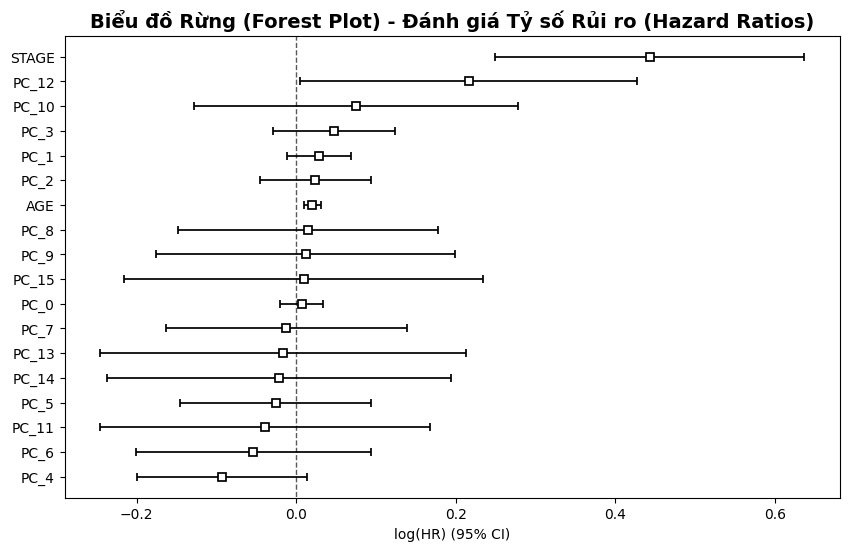

In [21]:
plt.figure(figsize=(10, 6))
cph.plot()
plt.title("Biểu đồ Rừng (Forest Plot) - Đánh giá Tỷ số Rủi ro (Hazard Ratios)", fontsize=14, fontweight='bold')
plt.show()

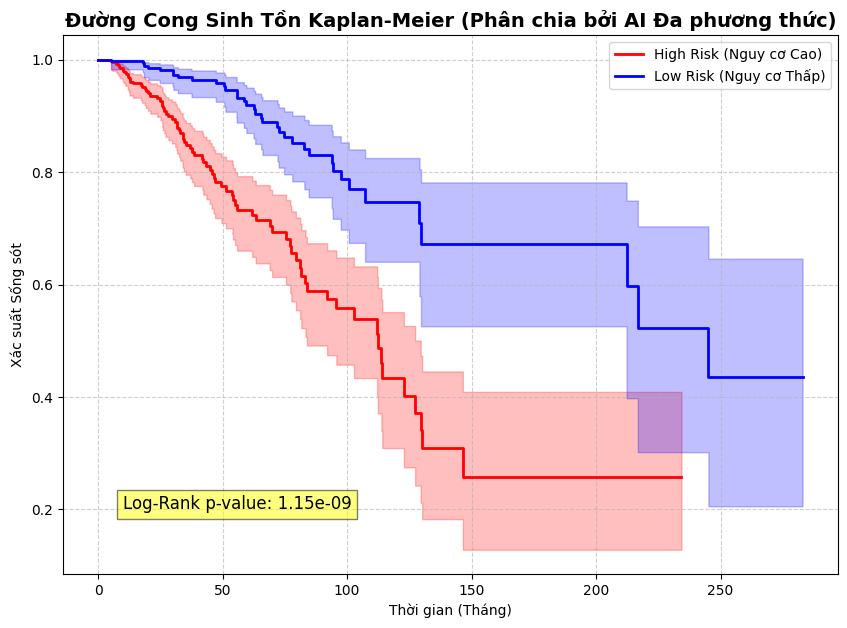

In [22]:
# Dự đoán Risk Score từ Cox Model
surv_df['Risk_Score'] = cph.predict_partial_hazard(surv_df)
median_risk = surv_df['Risk_Score'].median()

high_risk = surv_df[surv_df['Risk_Score'] > median_risk]
low_risk = surv_df[surv_df['Risk_Score'] <= median_risk]

results = logrank_test(high_risk['OS_MONTHS'], low_risk['OS_MONTHS'], 
                       high_risk['OS_STATUS'], low_risk['OS_STATUS'])
p_value = results.p_value

plt.figure(figsize=(10, 7))
kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()

kmf_high.fit(high_risk['OS_MONTHS'], event_observed=high_risk['OS_STATUS'], label='High Risk (Nguy cơ Cao)')
kmf_low.fit(low_risk['OS_MONTHS'], event_observed=low_risk['OS_STATUS'], label='Low Risk (Nguy cơ Thấp)')

kmf_high.plot_survival_function(color='red', lw=2)
kmf_low.plot_survival_function(color='blue', lw=2)

plt.title("Đường Cong Sinh Tồn Kaplan-Meier (Phân chia bởi AI Đa phương thức)", fontsize=14, fontweight='bold')
plt.xlabel("Thời gian (Tháng)")
plt.ylabel("Xác suất Sống sót")
plt.text(10, 0.2, f"Log-Rank p-value: {p_value:.2e}", fontsize=12, bbox=dict(facecolor='yellow', alpha=0.5))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
# -------------------------------------------------------------
# XUẤT TOÀN BỘ KẾT QUẢ SINH TỒN VÀO WORKING DIR
# -------------------------------------------------------------
surv_df['Risk_Group'] = surv_df['Risk_Score'].apply(lambda x: 'High_Risk' if x > median_risk else 'Low_Risk')
surv_df.to_csv("/kaggle/working/patient_survival_risk_scores.csv")
cph.summary.to_csv("/kaggle/working/coxph_summary_table.csv")

# Xuất bảng metrics tổng hợp C-Index
metrics_surv_df = pd.DataFrame([{
    'Model': 'Multimodal TransMIL + CoxPH',
    'C_Index': cph.concordance_index_,
    'LogRank_p_value': results.p_value,
    'High_Risk_Patients': len(high_risk),
    'Low_Risk_Patients': len(low_risk)
}])
metrics_surv_df.to_csv("/kaggle/working/survival_cindex_metrics.csv", index=False)
print("✓ Đã lưu patient_survival_risk_scores.csv, coxph_summary_table.csv và survival_cindex_metrics.csv vào /kaggle/working/")

## Slide 5: CASE STUDY DEMO (Cá nhân hóa Tiên lượng)
<div class="alert alert-success">
Sức mạnh thực sự của Y tế Cá nhân hóa (Personalized Medicine) là đây! Hãy tưởng tượng bạn là Bác sĩ, bệnh nhân này vừa bước vào phòng khám của bạn. AI không chỉ chẩn đoán bệnh mà còn <strong>vẽ ra chính xác quỹ đạo sinh tồn</strong> của riêng họ trong 10 năm tới.
</div>

 HỒ SƠ BỆNH NHÂN: TCGA-BH-A201
 Tuổi: 64 | Giai đoạn khối u: Stage 1
 Sự thật lâm sàng: CÒN SỐNG (sau 28.14215735 tháng)


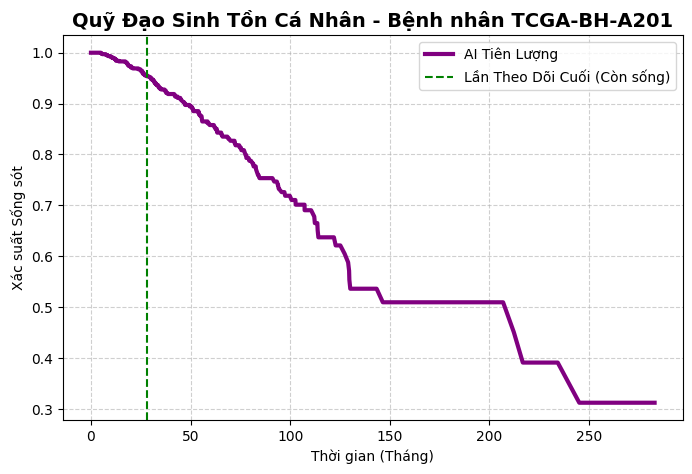

In [23]:
import random

# Bốc ngẫu nhiên 1 bệnh nhân
demo_pid = random.choice(valid_pids)
patient_row = surv_df.loc[[demo_pid]]

real_months = patient_row['OS_MONTHS'].values[0]
real_status = "ĐÃ TỬ VONG" if patient_row['OS_STATUS'].values[0] == 1 else "CÒN SỐNG"
age = patient_row['AGE'].values[0]
stage = patient_row['STAGE'].values[0]

print(f"==============================================")
print(f" HỒ SƠ BỆNH NHÂN: {demo_pid}")
print(f" Tuổi: {age} | Giai đoạn khối u: Stage {stage}")
print(f" Sự thật lâm sàng: {real_status} (sau {real_months} tháng)")
print(f"==============================================")

# Yêu cầu CoxPH vẽ đường cong tiên lượng riêng cho bệnh nhân này
patient_survival = cph.predict_survival_function(patient_row)

plt.figure(figsize=(8, 5))
plt.plot(patient_survival.index, patient_survival.iloc[:, 0], color='purple', lw=3, label='AI Tiên Lượng')

if patient_row['OS_STATUS'].values[0] == 1:
    plt.axvline(x=real_months, color='red', linestyle='--', label='Thời điểm Tử vong Thực tế')
    plt.scatter(real_months, patient_survival.loc[real_months].values[0] if real_months in patient_survival.index else patient_survival.iloc[(patient_survival.index - real_months).abs().argsort()[:1]].values[0], color='red', s=100, zorder=5)
else:
    plt.axvline(x=real_months, color='green', linestyle='--', label='Lần Theo Dõi Cuối (Còn sống)')

plt.title(f"Quỹ Đạo Sinh Tồn Cá Nhân - Bệnh nhân {demo_pid}", fontsize=14, fontweight='bold')
plt.xlabel("Thời gian (Tháng)")
plt.ylabel("Xác suất Sống sót")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()